In [1]:
import sys
sys.path.append("../utils/")
import utils as ut
import xarray as xr
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import hydro_storage as hs
import cftime
import datetime
import glob
import plot_config as pco
import string

# Open net load and storage values

In [2]:
path = "/net/xenon/climphys/lbloin/energy_boost/"
# Net load with hydropower dispatch, but without any spatial averaging
nl_hydro_by_country = {}
for scenario in  ut.CESM2_REALIZATION_DICT: #open for both climate periods
    net_load_hydro_by_country = xr.open_dataset(f"{path}net_load_by_country_hydro_storage_{scenario}.nc") 
    nl_hydro_by_country[scenario] = net_load_hydro_by_country

In [3]:
# Open full and mmaximum (installed capacity) storage levels from energy system optimization model (used for calibration)
# group by hour of day, then average
strg_levels_esm = []
storage_max_esm = []
for i,scenario in enumerate(["historical","SSP370"]):
    storage = hs.open_storage(scenario,'')
    strg_levels_esm.append(storage.groupby("time.hour").mean())
    storage_max_esm.append(storage.max(("time","member")))
strg_levels_esm = xr.concat(strg_levels_esm,dim="climate")
storage_max_esm = xr.concat(storage_max_esm,dim="climate").max("climate")

In [4]:
# Open storage levels from our dispatch model
# group by hour of day, then average
strgs_dispatch = []
for i,scenario in enumerate(["historical","SSP370"]):
    strgs_dispatch.append(nl_hydro_by_country[scenario].storage.sel(heating_scenario="fully_electrified", capacity_scenario="future").groupby("time.hour").mean())
strg_dispatch = xr.concat(strgs_dispatch,dim="climate")

# Plot

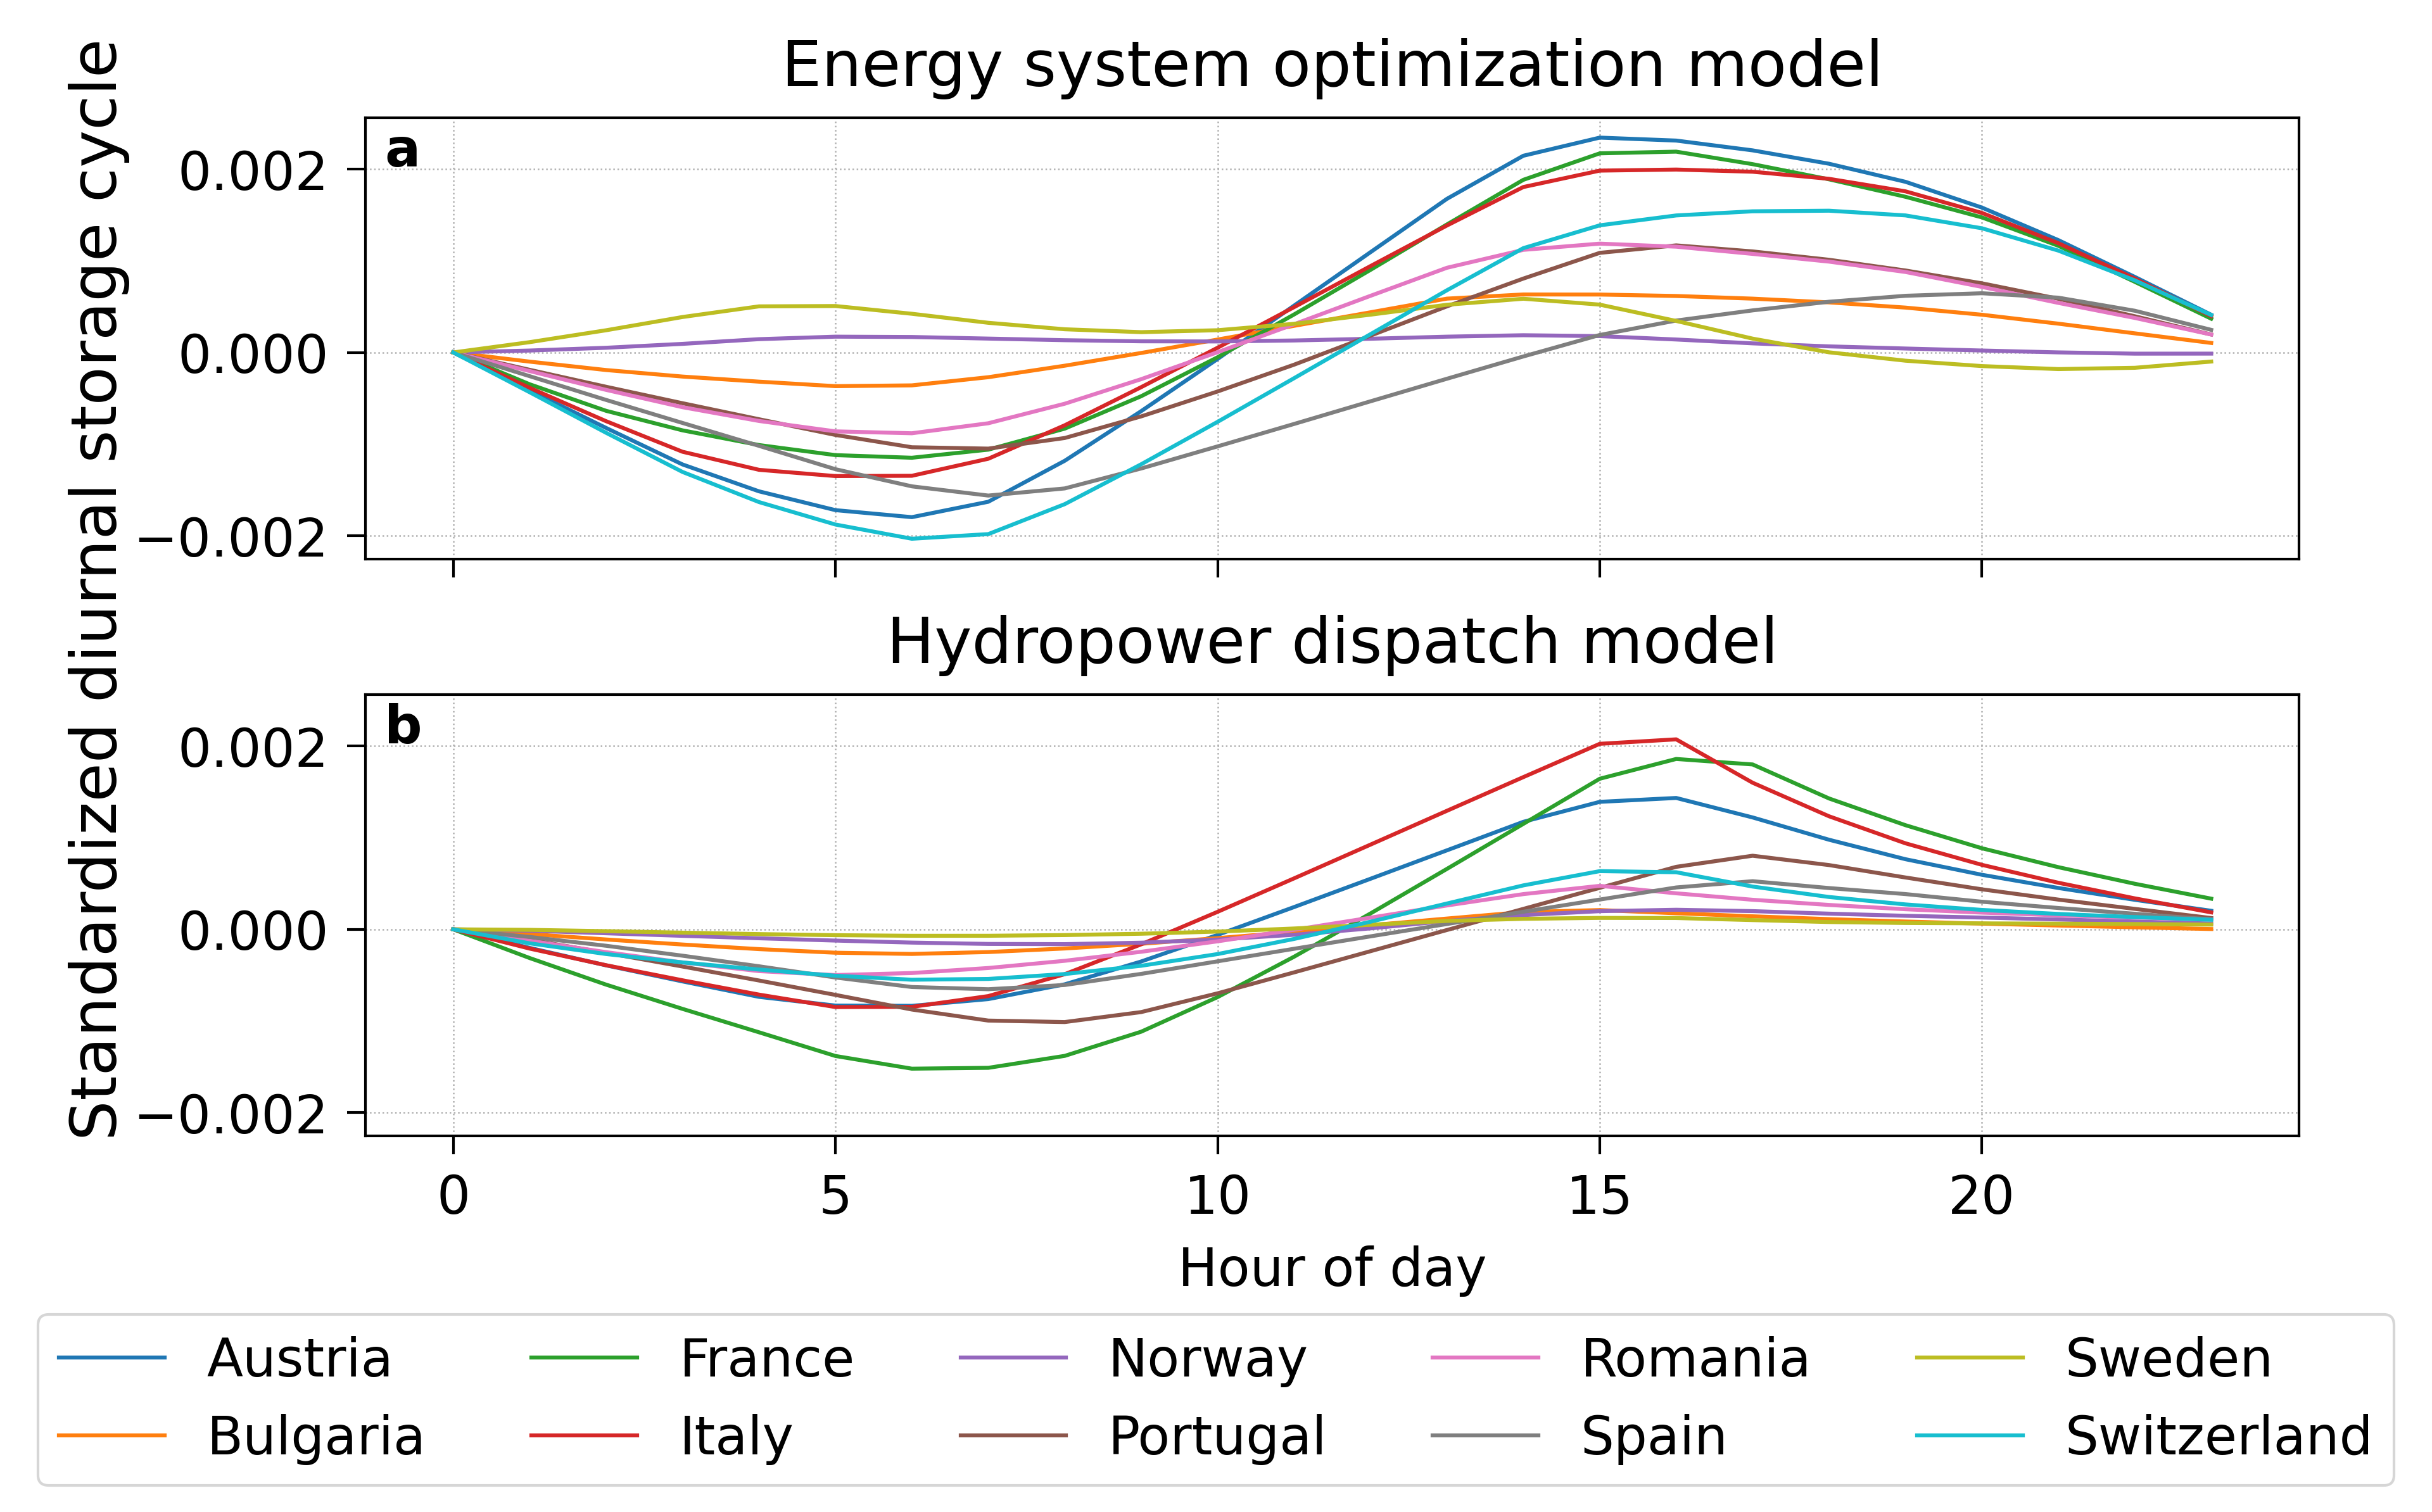

In [5]:
tit = ["Energy system optimization model", "Hydropower dispatch model","Hydropower dispatch model"]
f,ax=plt.subplots(2,1,figsize=(6,4),sharex=True,sharey=True)
for i,strg in enumerate([strg_levels_esm,strg_dispatch]):
    strg_mn = strg.mean(("member","climate"))/storage_max_esm
    for country in ["Austria","Bulgaria","France","Italy","Norway","Portugal","Romania","Spain","Sweden","Switzerland"]:
        if i ==0:
            extra=""
        else:
            extra="__"
        strg_country = strg_mn.sel(country=country)
        strg_rel = strg_country - strg_country[0]
        strg_rel.plot(label=f"{extra}{country}",ax=ax[i])
    ax[i].set_ylabel("")
    ax[i].set_title(tit[i])
    pco.set_grid(ax[i])
    ax[i].text(0.01,0.89,string.ascii_lowercase[i],weight="bold",transform=ax[i].transAxes)
ax[0].set_xlabel("")
ax[1].set_xlabel("Hour of day")
f.text(0.01,0.6,"Standardized diurnal storage cycle",rotation='vertical',verticalalignment='center', horizontalalignment='center',fontsize=12) 
f.legend(ncols=5,loc="lower center")
f.tight_layout()
f.subplots_adjust(bottom=0.24)
f.savefig("../../figs_CC_impacts/diurnal_cycle_of_storage.png",bbox_inches="tight", transparent=True, dpi =600)